MODULO DEEP LEARNING

FASE 1: ENTENDIMIENTO DEL NEGOCIO

1.1 Resumen

El conjunto de datos presenta transacciones que ocurrieron en dos días, donde tenemos 492 fraudes de 284.807 transacciones.
El conjunto de datos está altamente desequilibrado.

Variables:
    * V1, V2,... V28 -> son los componentes principales obtenidos con PCA
    * Tiempo y Cantidad 
    * Tiempo -> contiene los segundos transcurridos entre cada transacción y la primera transacción en el conjunto de datos.
    * Amount -> Monto de la transacción
    * Clase -> Variable de respuesta(Target) donde 1 = Fraude, 0 = No Fraude

1.2 Objetivo

Identificar los clientes propensos a realizar transacciones
fraudulentas.

FASE 2: COMPRENSION DE LOS DATOS

2.1 Configuracion e Importacion de Librerias

In [68]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [69]:
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score, roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
)

In [71]:
# Definir semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

2.2 Carga y Exploracion de Datos (EDA)

In [72]:
df = pd.read_csv('./../data/raw/creditcard.csv')
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [74]:
# Revisamos las dimensiones del dataset
df.shape

(284807, 31)

In [75]:
#Revisamos el target(Clase)
# 1 = Fraude
# 0 = No Fraude
df['Class'].value_counts() #Validamos que realmente es un dataset desbalanceado

Class
0    284315
1       492
Name: count, dtype: int64

/tmp/ipykernel_62134/2437454876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=["#67db67", '#d9534f'])


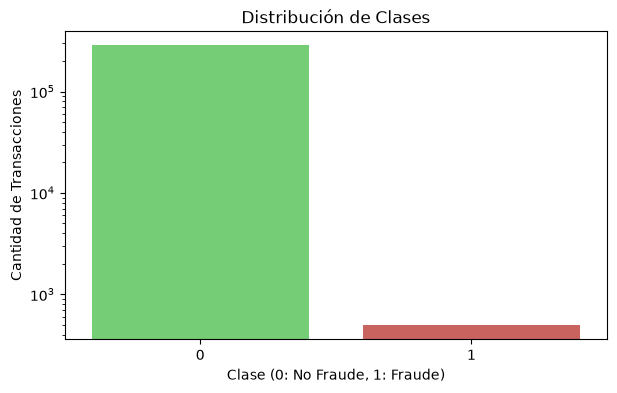

In [76]:
# Gráfico para verificar el desbalanceo
plt.figure(figsize=(7, 4))
sns.countplot(x='Class', data=df, palette=["#67db67", '#d9534f'])
plt.yscale('log')
plt.title('Distribución de Clases')
plt.xlabel('Clase (0: No Fraude, 1: Fraude)')
plt.ylabel('Cantidad de Transacciones')
plt.show()

In [77]:
# Revisamos los estadísticos de las variables numéricas
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


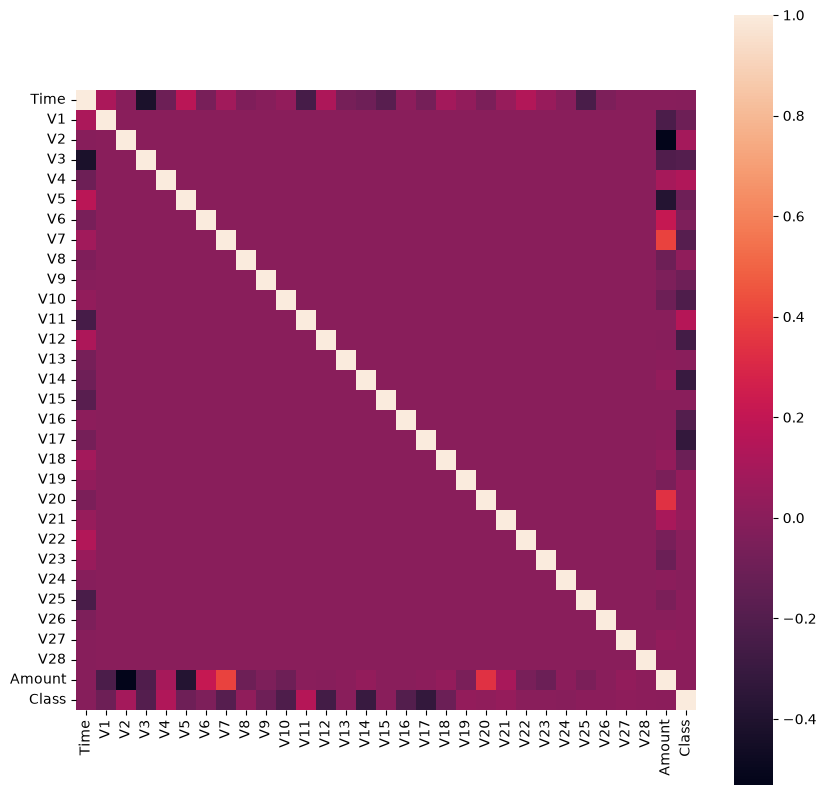

In [78]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), square=True)
plt.show()

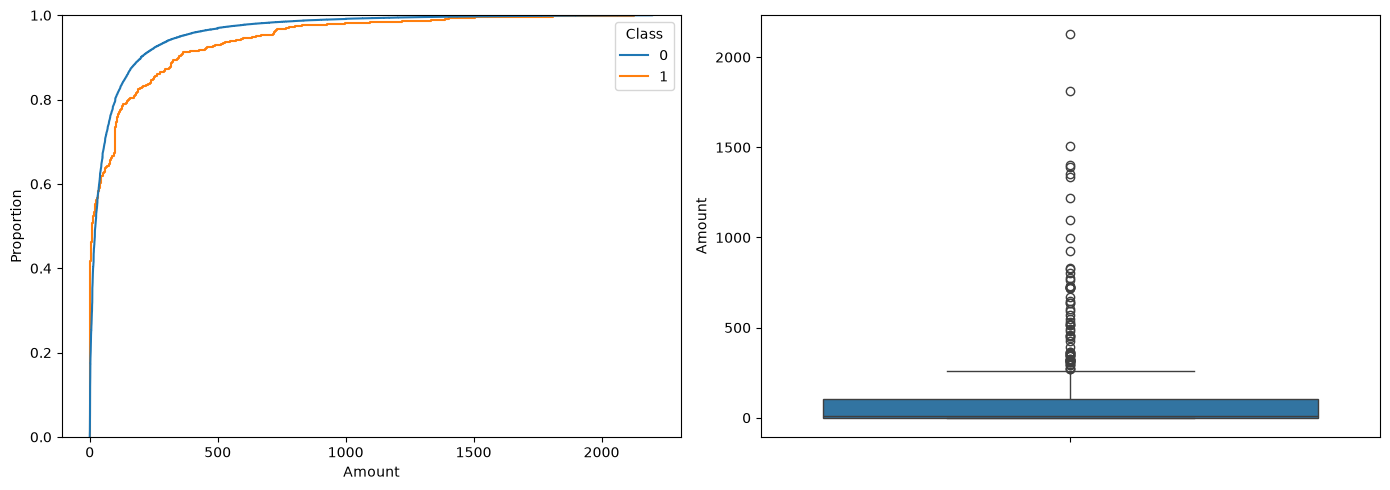

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [79]:
# Comparamos Monto y Clase
fig, axes = plt.subplots(1, 2, figsize=(14,5))

df_fraud = df[df['Class'] == 1]

sns.ecdfplot(
    data=df[df['Amount'] < 2200],
    x='Amount',
    hue='Class',
    ax=axes[0]
)

sns.boxplot(
    df_fraud,
    y= 'Amount',
    ax=axes[1]
)

plt.tight_layout()
plt.show()

df_fraud['Amount'].describe()

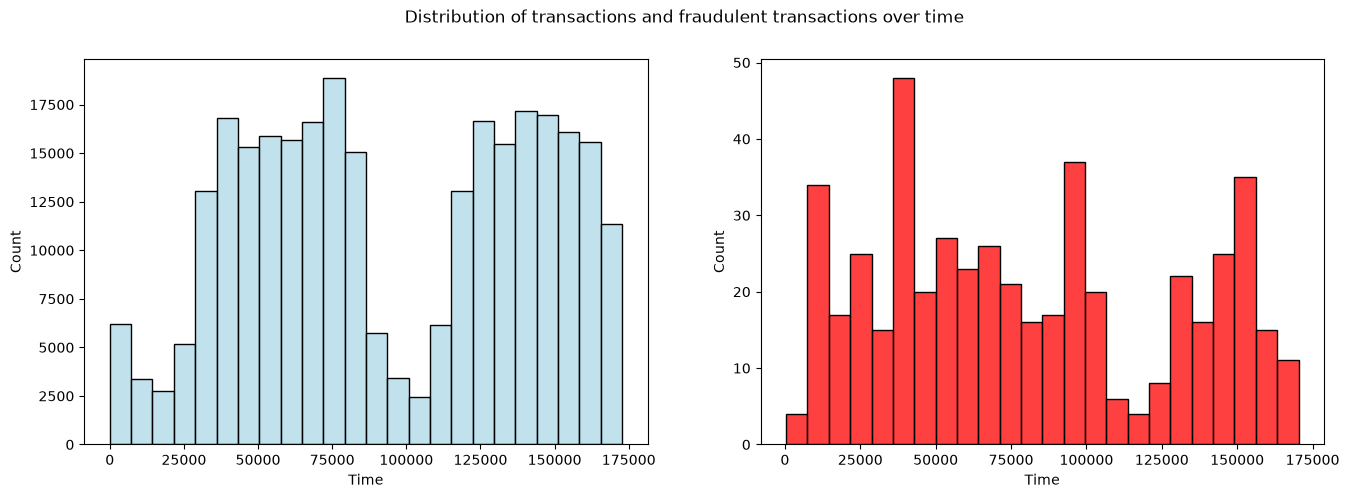

In [80]:
# Horarios en los que se realizan las transacciones fraudulentas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=df,
    x='Time',
    bins=24,
    color='lightblue',
    ax=axes[0]
)


sns.histplot(
    data=df_fraud,
    x='Time',
    bins=24,
    color='red',
    ax=axes[1]
)

plt.suptitle('Distribution of transactions and fraudulent transactions over time')
plt.show()

FASE 3: PREPARACION DE LOS DATOS

3.1 Partición y Escalamiento de datos

In [81]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [82]:
# Escalado de 'Time' y 'Amount' mediante RobustScaler
scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

In [83]:
df.drop(['Time', 'Amount'], axis=1, inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

In [84]:
# Partición estratificada (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

FASE 4: MODELADO

4.1 Multilayer Perceptron(MLP) Neural Network

In [85]:
input_dim = X_train.shape[1]

In [86]:
# Cálculo de pesos para contrarrestar el desbalance de clases (0.172% fraudes)
neg_count, pos_count = np.bincount(y_train)
weight_0 = (1 / neg_count) * (len(y_train) / 2.0)
weight_1 = (1 / pos_count) * (len(y_train) / 2.0)
class_weights = {0: weight_0, 1: weight_1}

In [87]:
# Construcción de la arquitectura MLP
mlp_model = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name="MLP_Supervisado")

In [88]:
mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='PR', name='pr_auc'), 'accuracy']
)

In [89]:
# Callbacks: Guardar mejor modelo en formato .keras
checkpoint_mlp = ModelCheckpoint('modelos/modelo_mlp.keras', monitor='val_pr_auc', mode='max', save_best_only=True)
early_stop_mlp = EarlyStopping(monitor='val_pr_auc', mode='max', patience=5, restore_best_weights=True)

history_mlp = mlp_model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=2048,
    class_weight=class_weights,
    callbacks=[early_stop_mlp, checkpoint_mlp],
    verbose=1
)

Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6633 - loss: 0.4950 - pr_auc: 0.1078 - val_accuracy: 0.9427 - val_loss: 0.4143 - val_pr_auc: 0.5731
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8350 - loss: 0.3336 - pr_auc: 0.1611 - val_accuracy: 0.9633 - val_loss: 0.2661 - val_pr_auc: 0.6203
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9033 - loss: 0.2599 - pr_auc: 0.1923 - val_accuracy: 0.9708 - val_loss: 0.2038 - val_pr_auc: 0.6344
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9362 - loss: 0.2217 - pr_auc: 0.2610 - val_accuracy: 0.9799 - val_loss: 0.1571 - val_pr_auc: 0.6834
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9455 - loss: 0.2038 - pr_auc: 0.2503 - val_accuracy: 0.9760 - val_loss: 0.1430 - val_pr_auc: 0.6513
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9531 - loss: 0.1916 - pr_auc: 0.2629 - val_accuracy: 0.9800 - val_loss: 0.1263 - val_pr_auc: 0.6694
Epoch 7/30
95/95

In [90]:
# Predicción MLP
y_probs_mlp = mlp_model.predict(X_test, batch_size=2048).ravel()

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


4.2 Autoencode

In [91]:
# Entrenar Autoencoder ÚNICAMENTE con la clase legítima (Class == 0)
X_train_normal = X_train[y_train == 0]

In [92]:
encoding_dim = 14  # Reducción de dimensionalidad intermedia

In [93]:
input_layer = Input(shape=(input_dim,))
encoder = Dense(20, activation='tanh')(input_layer)
encoder = Dense(encoding_dim, activation='relu')(encoder)

In [94]:
decoder = Dense(20, activation='tanh')(encoder)
decoder = Dense(input_dim, activation='linear')(decoder)

In [95]:
autoencoder = Model(inputs=input_layer, outputs=decoder, name="Autoencoder_Anomalias")

In [96]:
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

In [97]:
checkpoint_ae = ModelCheckpoint('modelos/modelo_autoencoder.keras', monitor='val_loss', mode='min', save_best_only=True)
early_stop_ae = EarlyStopping(monitor='val_loss', mode='min', patience=5, restore_best_weights=True)

history_ae = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=30,
    batch_size=2048,
    validation_split=0.15,
    callbacks=[early_stop_ae, checkpoint_ae],
    verbose=1
)

Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3082 - val_loss: 1.1103
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0141 - val_loss: 0.9151
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8624 - val_loss: 0.7872
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7489 - val_loss: 0.6852
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6582 - val_loss: 0.6040
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5909 - val_loss: 0.5494
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5460 - val_loss: 0.5110
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5116 - val_loss: 0.4803
Epoch 9/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4844 - val_loss: 0.4569
Epoch 10/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4636 - val_loss: 0.4389
Epoch 11/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4472 - val_loss: 0.4243
Epoch 12/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4332 - val_lo

In [98]:
# Cálculo del error de reconstrucción (MSE) como 'score' de fraude
X_test_pred = autoencoder.predict(X_test, batch_size=2048)
mse = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [99]:
# Normalizar el MSE entre 0 y 1 para comparabilidad
y_probs_ae = (mse - mse.min()) / (mse.max() - mse.min())

FASE 5: EVALUACION

In [100]:
predictions = {
    'DL 1: MLP Supervisado': y_probs_mlp,
    'DL 2: Autoencoder': y_probs_ae
}

In [101]:
results = []

plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

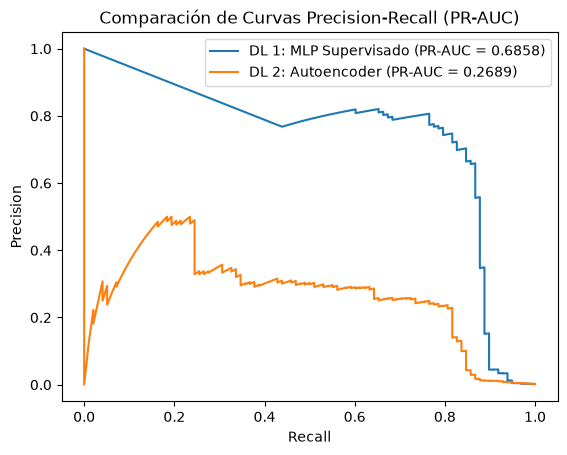

In [102]:
for name, probs in predictions.items():
    pr_auc = average_precision_score(y_test, probs)
    roc_auc = roc_auc_score(y_test, probs)
    
    # Evaluar con umbral estándar (0.5)
    preds = (probs >= 0.5).astype(int)
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    
    results.append({
        'Modelo': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })
    
    # Graficar Curva Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, probs)
    plt.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Comparación de Curvas Precision-Recall (PR-AUC)')
plt.legend()
plt.show()

In [103]:
# Mostrar Tabla Comparativa Resumen
df_res = pd.DataFrame(results)
print("\n" + "="*80)
print("TABLA COMPARATIVA DE MODELOS DE DEEP LEARNING")
print("="*80)
print(df_res.to_string(index=False))


TABLA COMPARATIVA DE MODELOS DE DEEP LEARNING
               Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
DL 1: MLP Supervisado  0.985587   0.097887 0.897959   0.17653 0.968516 0.685750
    DL 2: Autoencoder  0.998244   0.000000 0.000000   0.00000 0.963556 0.268877
